<a href="https://colab.research.google.com/github/neerajkm1708/linkshortenerproject/blob/main/MarketingCampaigns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem scenario:
Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.

#Problem objective:
As a data scientist, you must conduct exploratory data analysis (EDA) and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

#Data description:
The variables such as birth year, education, income, and others pertain to the first 'P' or 'People' in the tabular data presented to the user. The expenditures on items like wine, fruits, and gold, are associated with ‘Product’. Information relevant to sales channels, such as websites and stores, is connected to ‘Place’, and the fields discussing promotions and the outcomes of various campaigns are linked to ‘Promotion’.




#Steps to perform For Analysis:

1.	After importing the data, examine variables such as Dt_Customer and Income to verify their accurate importation.

2.	There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.

3.	Create variables to represent the total number of children, age, and total spending.

a.	Derive the total purchases from the number of transactions across the three channels.

4.	Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

5.	Apply ordinal and one-hot encoding based on the various types of categorical variables.

6.	Generate a heatmap to illustrate the correlation between different pairs of variables.

7.	Test the following hypotheses:
a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.
b.	Customers with children likely experience time constraints, making online shopping a more convenient option.
c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.
d.	Does the United States significantly outperform the rest of the world in total purchase volumes?


8.	Use appropriate visualization to help analyze the following:
a.	Identify the top-performing products and those with the lowest revenue.
b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.
c.	Determine the country with the highest number of customers who accepted the last campaign.
d.	Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
e.	Analyze the educational background of customers who lodged complaints in the last two years.


# Import Necessary Libraries

In [1]:
# Import necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1 - Import data [marketing_data] File to Pandas Data frame for analysis

In [2]:
df = pd.read_csv('sample_data/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


# Gather Details About Data Structure, Type Of data, Rows, Columns, and Values


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [4]:
# df.columns
# df[' Income ']


Summary (df.Info()):
*   Total 2240 Rows and 28 columns present in the data set
*   Income Column contains Null value8 (2240 - 2216 = 24 (null values)
*   Income Column name, containing a space at the start, verify with  [df.columns] or df[' Income ']
*   Income Column Contain Currency Symbols
*   Dt_Customer is a Date type Object, not null, but check values for valid date  





In [5]:
df.describe()

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Examine Columns / Feature / Variables, such as **Dt_Customer** and **Income** to verify their accurate importation.

* Income Column name, containing a space at the start, verify with [df.columns] or df[' Income ']

* Income Column Contain Currency Symbols

In [6]:
# Rename ' Income ' column
df.rename(columns={' Income ':'Income'}, inplace=True)


In [7]:
df["Income"].unique()
#Extract Currency symbol $ from Income Column
df['currency_symbol']= df['Income'].str.extract(r'([^\d\.,\s]+)')
df['currency_symbol'] = df['currency_symbol'].fillna('$')


In [8]:
#replace $ Symbol from Income Column
df['Income'] = df['Income'].str.replace(r'\$', '', regex=True)
df['Income'] = df['Income'].str.replace(" ", '', regex=True)

In [9]:
# Convert Income Column string value to to float value
df['Income'] = df['Income'].str.replace(",", '', regex=True)
df['Income'] = df['Income'].astype(float)



In [10]:
# In Income column there are NaN Values in 24 Rows, Fill those values with appropriate value
df['Income'].isna().sum()

df.groupby(['Education', 'Marital_Status'])['Income'].mean()

# print(df["Education"].unique())
# df[df["Income"].isna()]["Education"].unique()



Education   Marital_Status
2n Cycle    Divorced          49395.130435
            Married           46201.100000
            Single            53673.944444
            Together          44736.410714
            Widow             51392.200000
Basic       Divorced           9548.000000
            Married           21960.500000
            Single            18238.666667
            Together          21240.071429
            Widow             22123.000000
Graduation  Absurd            79244.000000
            Alone             34176.000000
            Divorced          54526.042017
            Married           50800.258741
            Single            51322.182927
            Together          55758.480702
            Widow             54976.657143
Master      Absurd            65487.000000
            Alone             61331.000000
            Divorced          50331.945946
            Married           53286.028986
            Single            53530.560000
            Together          52109.009804
            Widow             58401.545455
PhD         Alone             35860.000000
            Divorced          53096.615385
            Married           58138.031579
            Single            53314.614583
            Together          56041.422414
            Widow             60288.083333
            YOLO              48432.000000
Name: Income, dtype: float64

In [11]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,currency_symbol
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,1,0,0,0,0,0,1,0,SP,$
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,5,0,0,0,0,1,1,0,CA,$
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,2,0,0,0,0,0,0,0,US,$
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,7,0,0,0,0,0,0,0,AUS,$
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,7,1,0,0,0,0,1,0,SP,$
5,7348,1958,PhD,Single,71691.0,0,0,3/17/14,0,336,...,2,0,0,0,0,0,1,0,SP,$
6,4073,1954,2n Cycle,Married,63564.0,0,0,1/29/14,0,769,...,6,1,0,0,0,0,1,0,GER,$
7,1991,1967,Graduation,Together,44931.0,0,1,1/18/14,0,78,...,5,0,0,0,0,0,0,0,SP,$
8,4047,1954,PhD,Married,65324.0,0,1,1/11/14,0,384,...,4,0,0,0,0,0,0,0,US,$
9,9477,1954,PhD,Married,65324.0,0,1,1/11/14,0,384,...,4,0,0,0,0,0,0,0,IND,$


 <!-- Pandas Profiling before Data Preprocessing -->

In [12]:
!pip install https://github.com/ydataai/pandas-profiling/archive/master.zip

     / 17.9 MB 25.0 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.2 MB/s eta 0:00:00
  Created wheel for fg-data-profiling: filename=fg_data_profiling-0.0.dev0-py2.py3-none-any.whl size=400299 sha256=2dc658412ec307a95efd69b17542093d0d3ec678a17c93b01740972823e4f033
  Stored in directory: /tmp/pip-ephem-wheel-cache-s8iky6n6/wheels/4b/65/54/21d174ef238622146302066649fd4bbf6d843c022033c4d5ec
Successfully built fg-data-profiling


In [13]:
import ydata_profiling as pandas_profiling

/tmp/ipykernel_5247/2488484915.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  import ydata_profiling as pandas_profiling


In [14]:
# To output pandas profiling report to an external html file.
# Saving the output as profiling_before_preprocessing.html
'''
profile = df.profile_report(title='Pandas Profiling before Marketing Data Preprocessing')
profile.to_file(output_file="Marketing_profiling_before_preprocessing.html")
'''

# To output the pandas profiling report on the notebook.
profile = pandas_profiling.ProfileReport(df)

profile.to_file(output_file="Marketing_profiling_before_preprocessing.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 29/29 [00:01<00:00, 18.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
df.columns
df[df["Income"].isna() != True].dtypes
# df.groupby(['Education', 'Marital_Status'])['Income'].mean()

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


#2.	There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.

In [16]:
# df['Education'] .unique() # array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)
# df['Marital_Status'].unique() # array(['Married', 'Together', 'Single', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO'], dtype=object)

# Transforming data by group
df['Income'] = df['Income'].fillna(df.groupby(['Education', 'Marital_Status'])['Income'].transform('mean'))


# Convert Date column [Dt_Customer], which is string to Date Time

In [17]:
print(type(df["Dt_Customer"][0]))

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

print(type(df["Dt_Customer"][0]))
type(df["Dt_Customer"][0])

<class 'str'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


/tmp/ipykernel_5247/2885923769.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


pandas._libs.tslibs.timestamps.Timestamp

a.	Derive the total purchases from the number of transactions across the three channels.


In [18]:
  # Derive the total purchases from the number of transactions across the three channels.
  df["total_purchases"] =  df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"]

In [19]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,currency_symbol,total_purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,0,1,0,SP,$,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,0,0,1,1,0,CA,$,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,0,0,US,$,10
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,0,0,AUS,$,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,1,0,0,0,0,1,0,SP,$,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,0,0,US,$,18
2236,5263,1977,2n Cycle,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,0,0,0,0,SP,$,4
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,0,0,SP,$,12
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,0,0,0,0,IND,$,19


In [20]:
# feature Engeniering
df['Age'] = 2026 - df['Year_Birth'] # Assuming 2026 as the study year
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

<Axes: xlabel='Income'>

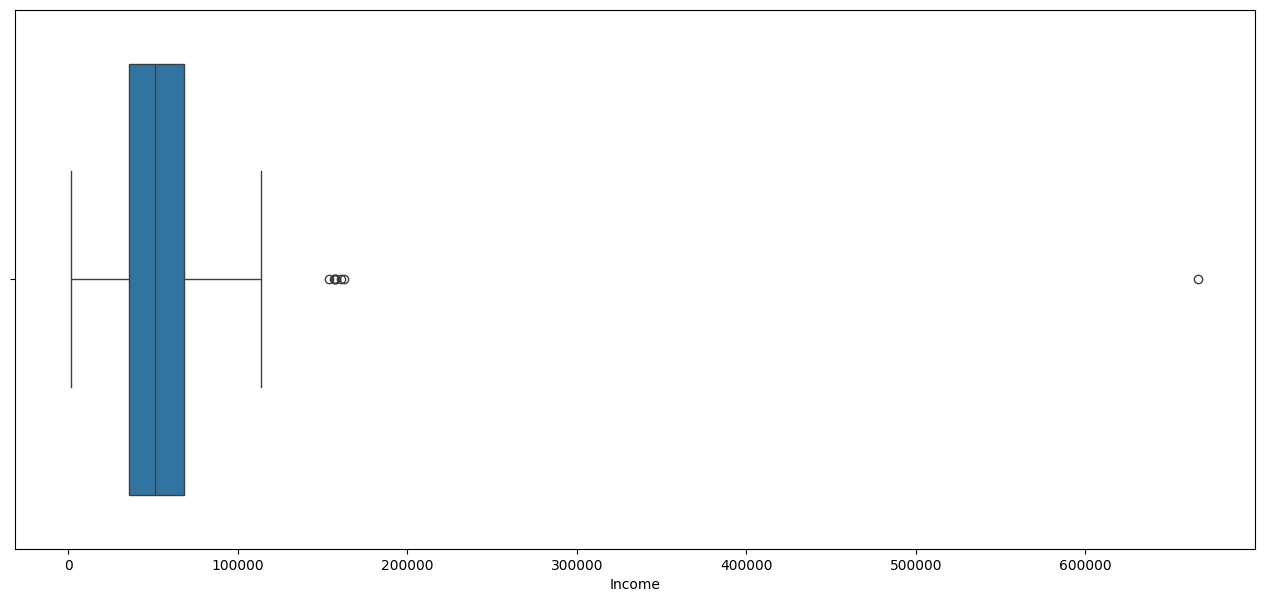

In [21]:
# Create Box Plot to identfy the outlier
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='Income')
# plt.xticks(rotation=90)

In [22]:
df[df['Income'] >= 150000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Response,Complain,Country,currency_symbol,total_purchases,Age,Children,Total_Spending,Total_Purchases
325,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,...,0,0,0,SA,$,28,49,0,1730,28
497,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,...,0,0,0,US,$,29,44,0,1717,29
527,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,0,0,0,SA,$,7,49,1,62,7
731,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,...,0,0,0,SP,$,1,50,2,107,1
853,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,...,0,0,0,SP,$,2,55,1,59,2
1826,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,...,0,0,0,SP,$,0,51,0,6,0
1925,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,...,0,0,0,CA,$,0,77,0,8,0
2204,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,...,0,0,0,IND,$,22,53,1,1608,22


In [23]:
# Deleting the Income Outlier records
df.drop(df[df['Income'] >= 150000].index, inplace=True)


<Axes: xlabel='Age'>

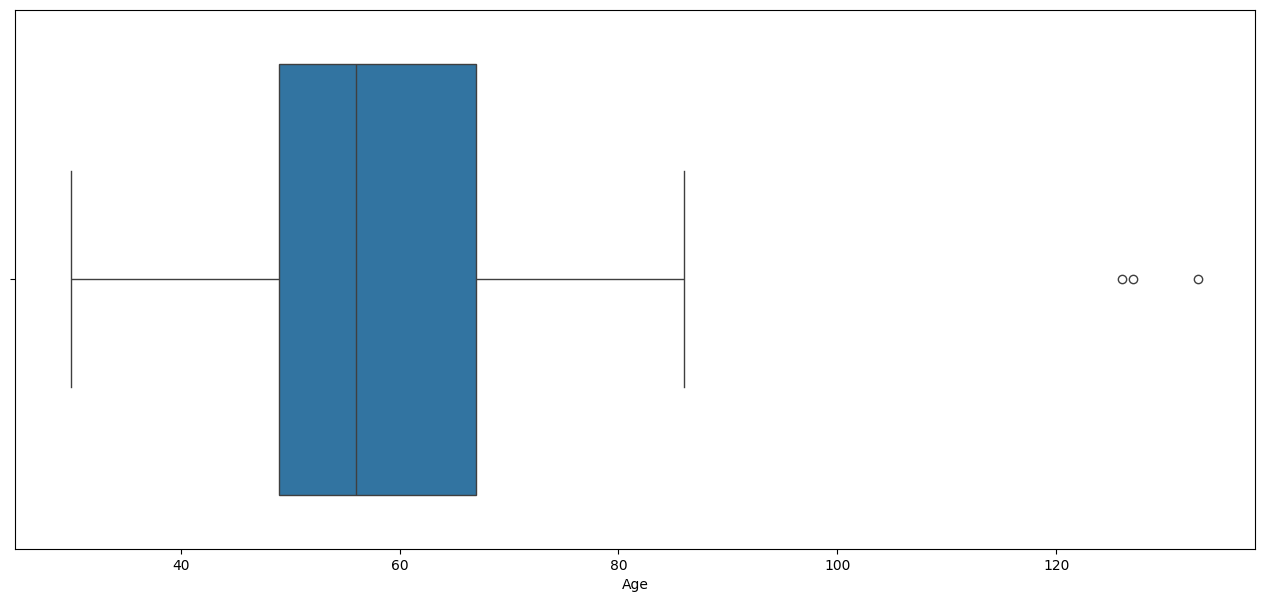

In [24]:
# Now Check The out liar from the Age Column by creating the Box plot
# Create Box Plot to identfy the outlier
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='Age')


In [25]:
print(df[df["Age"]> 100])
df.drop(df[df["Age"]> 100].index, inplace=True)

         ID  Year_Birth Education Marital_Status   Income  Kidhome  Teenhome  \
513   11004        1893  2n Cycle         Single  60182.0        0         1   
827    1150        1899       PhD       Together  83532.0        0         0   
2233   7829        1900  2n Cycle       Divorced  36640.0        1         0   

     Dt_Customer  Recency  MntWines  ...  AcceptedCmp2  Response  Complain  \
513   2014-05-17       23         8  ...             0         0         0   
827   2013-09-26       36       755  ...             0         0         0   
2233  2013-09-26       99        15  ...             0         0         1   

      Country  currency_symbol  total_purchases  Age  Children  \
513        SA                $                3  133         1   
827        SP                $               14  127         0   
2233      IND                $                5  126         1   

      Total_Spending  Total_Purchases  
513               22                3  
827             1853 

In [26]:
# 5. Encoding Categorical Variables
# Ordinal for Education
edu_map = {'Basic': 1, 'Graduation': 2, '2n Cycle': 3, 'Master': 4, 'PhD': 5}
df['Education_Rank'] = df['Education'].map(edu_map)

# One-hot encoding  for Marital Status
df = pd.get_dummies(df, columns=['Marital_Status'], prefix=['marital_status'])



In [27]:
df

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Total_Purchases,Education_Rank,marital_status_Absurd,marital_status_Alone,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Together,marital_status_Widow,marital_status_YOLO
0,1826,1970,Graduation,84835.0,0,0,2014-06-16,0,189,104,...,14,2,False,False,True,False,False,False,False,False
1,1,1961,Graduation,57091.0,0,0,2014-06-15,0,464,5,...,17,2,False,False,False,False,True,False,False,False
2,10476,1958,Graduation,67267.0,0,1,2014-05-13,0,134,11,...,10,2,False,False,False,True,False,False,False,False
3,1386,1967,Graduation,32474.0,1,1,2014-05-11,0,10,0,...,3,2,False,False,False,False,False,True,False,False
4,5371,1989,Graduation,21474.0,1,0,2014-04-08,0,6,16,...,6,2,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,66476.0,0,1,2013-03-07,99,372,18,...,18,5,False,False,True,False,False,False,False,False
2236,5263,1977,2n Cycle,31056.0,1,0,2013-01-22,99,5,10,...,4,3,False,False,False,True,False,False,False,False
2237,22,1976,Graduation,46310.0,1,0,2012-12-03,99,185,2,...,12,2,False,False,True,False,False,False,False,False
2238,528,1978,Graduation,65819.0,0,0,2012-11-29,99,267,38,...,19,2,False,False,False,True,False,False,False,False


# Post Profiling - Panda Profilling After Marketing Data Processing


In [28]:
# To output pandas profiling report to an external html file.
# Saving the output as profiling_before_preprocessing.html
'''
profile = df.profile_report(title='Pandas Profiling After Marketing Data Preprocessing')
profile.to_file(output_file="Marketing_profiling_after_preprocessing.html")
'''

# To output the pandas profiling report on the notebook.
profile = pandas_profiling.ProfileReport(df)

profile.to_file(output_file="Marketing_profiling_after_preprocessing.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 42/42 [00:00<00:00, 74.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

6.	Generate a heatmap to illustrate the correlation between different pairs of variables.

In [29]:

df_new = df.loc[:, df.columns != 'Education']

df_new = df_new.loc[:, df_new.columns != 'Dt_Customer']

df_new = df_new.loc[:, df_new.columns != 'Year_Birth']

df_new = df_new.loc[:, df_new.columns != 'ID']

df_new = df_new.loc[:, df_new.columns != 'Country']

df_new = df_new.loc[:, df_new.columns != 'currency_symbol']

df_new = df_new.loc[:, df_new.columns != 'Kidhome']



df_new = df_new.loc[:, df_new.columns != 'Teenhome']


df_new = df_new.loc[:, df_new.columns != 'AcceptedCmp3']

df_new = df_new.loc[:, df_new.columns != 'AcceptedCmp4']

df_new = df_new.loc[:, df_new.columns != 'AcceptedCmp5']

df_new = df_new.loc[:, df_new.columns != 'AcceptedCmp1']

df_new = df_new.loc[:, df_new.columns != 'AcceptedCmp2']
df_new = df_new.loc[:, df_new.columns != 'Response']
df_new = df_new.loc[:, df_new.columns != 'Complain']



In [30]:
# To output pandas profiling report to an external html file.
# Saving the output as profiling_before_preprocessing.html
'''
profile = df.profile_report(title='Pandas Profiling After new Marketing Data Preprocessing')
profile.to_file(output_file="New_Marketing_profiling_after_preprocessing.html")
'''

# To output the pandas profiling report on the notebook.
profile = pandas_profiling.ProfileReport(df_new)

profile.to_file(output_file="New_Marketing_profiling_after_preprocessing.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 27/27 [00:00<00:00, 37.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
df_new.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Purchases,Education_Rank,marital_status_Absurd,marital_status_Alone,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Together,marital_status_Widow,marital_status_YOLO
0,84835.0,0,189,104,379,111,189,218,1,4,...,14,2,False,False,True,False,False,False,False,False
1,57091.0,0,464,5,64,7,0,37,1,7,...,17,2,False,False,False,False,True,False,False,False
2,67267.0,0,134,11,59,15,2,30,1,3,...,10,2,False,False,False,True,False,False,False,False
3,32474.0,0,10,0,1,0,0,0,1,1,...,3,2,False,False,False,False,False,True,False,False
4,21474.0,0,6,16,24,11,0,34,2,3,...,6,2,False,False,False,False,True,False,False,False


<Axes: >

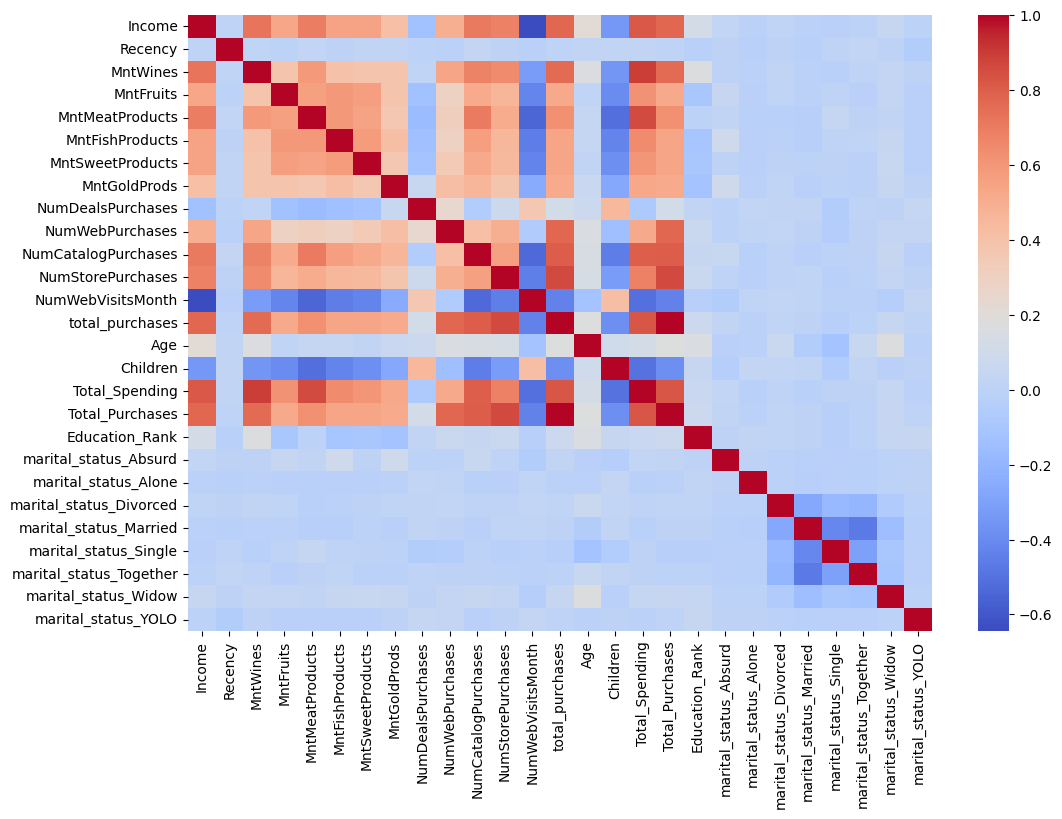

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(df_new.corr(), annot=False, cmap='coolwarm')

7.	Test the following hypotheses:

a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.

(Age vs NumStorePurchases): Calculate the correlation between Age and NumStorePurchases. If positive and significant, older people prefer stores.

b.	Customers with children likely experience time constraints, making online shopping a more convenient option.

(Children vs Online): Compare the mean of NumWebPurchases for customers with children vs. those without using a T-test.

c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

(Cannibalization): Look for negative correlations between NumStorePurchases and NumWebPurchases. A positive correlation usually suggests general high engagement, not cannibalization.

d.	Does the United States significantly outperform the rest of the world in total purchase volumes?

(USA vs World): Compare the mean of Total_Purchases for Country == 'USA' against all other countries combined using a T-test.


In [33]:
#(Age vs NumStorePurchases): Calculate the correlation between Age and NumStorePurchases.
#If positive and significant, older people prefer stores.

df_new.columns
df_new[["Age", "NumStorePurchases"]]


,Age,NumStorePurchases
0,56,6
1,65,7
2,68,5
3,59,2
4,37,2
...,...,...
2235,50,11
2236,49,3
2237,50,5
2238,48,10


In [ ]:
import scipy.stats as stats

# Lets Assume the Significase Value (Critical Value) is provided by Domain Expert is 0.05
alpha = 0.05


# Calculate Pearson correlation and p-value
corr, p_value = stats.pearsonr(df_new['Age'], df_new['NumStorePurchases'])

print(f"Pearson Correlation Coefficient: {corr:.3f}")
print(f"P-value: {p_value:.3e}")


if corr > 0 and p_value < alpha:
    print("Result: Positive and significant. Older people prefer stores.")
else:
    print("Result: Not significant or not positively correlated.")

Pearson Correlation Coefficient: 0.139
P-value: 4.587e-11
Result: Positive and significant. Older people prefer stores.
